In [1]:
# Verbindung zu Google Drive aufbauen
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


✅ 5 Szenen gefunden:
  - LC08_L2SP_194025_20250701_20250711_02_T1
  - LC08_L2SP_194025_20250818_20250821_02_T1
  - LC08_L2SP_194025_20250919_20250929_02_T1
  - LC09_L2SP_194025_20250810_20250811_02_T1
  - LC09_L2SP_194025_20250826_20250902_02_T1
✅ 11 Gebiete geladen

🔄 LC08_L2SP_194025_20250701_20250711_02_T1
  ℹ️  ST_B10 NoData-Wert: 0.0
  ✔ Klare Pixel: 148,895 / 171,500 (86.8%)
  ✔ LST | Min: 24.2°C  Mean: 38.8°C  Max: 51.2°C
  ✔ Gespeichert: LC08_L2SP_194025_20250701_20250711_02_T1_LST_Celsius.tif

🔄 LC08_L2SP_194025_20250818_20250821_02_T1
  ℹ️  ST_B10 NoData-Wert: 0.0
  ✔ Klare Pixel: 171,500 / 171,500 (100.0%)
  ✔ LST | Min: 22.2°C  Mean: 31.8°C  Max: 43.8°C
  ✔ Gespeichert: LC08_L2SP_194025_20250818_20250821_02_T1_LST_Celsius.tif

🔄 LC08_L2SP_194025_20250919_20250929_02_T1
  ℹ️  ST_B10 NoData-Wert: 0.0
  ✔ Klare Pixel: 171,497 / 171,500 (100.0%)
  ✔ LST | Min: 21.9°C  Mean: 28.5°C  Max: 39.7°C
  ✔ Gespeichert: LC08_L2SP_194025_20250919_20250929_02_T1_LST_Celsius.tif

🔄 LC09_L2S

/tmp/ipykernel_1119/3154223423.py:174: RuntimeWarning: Mean of empty slice
  lst_mean = np.nanmean(lst_stack, axis=0)


✔ LST_MEAN gespeichert
  Mean: 32.3°C
  Min:  21.7°C
  Max:  45.0°C

Gebiet                       Mean     Min     Max     Std      n
  Rottenbauer-Nord          34.6°C    29.7°C    36.8°C  ± 1.6°C     468
  Rottenbauer-Süd           34.5°C    30.7°C    37.2°C  ± 1.1°C     481
  Lengfeld                  34.7°C    32.0°C    36.4°C  ± 0.9°C     178
  Lengfeld-Kern             34.7°C    29.5°C    37.4°C  ± 1.6°C     242
  Hubland Grünfläche        33.1°C    30.6°C    36.5°C  ± 1.6°C     229
  Hubland Terrassen         32.9°C    31.5°C    35.2°C  ± 0.9°C      59
  Hubland Quartier I        33.7°C    30.7°C    36.8°C  ± 1.4°C      70
  Hubland Quartier II       35.4°C    31.7°C    38.3°C  ± 2.0°C      32
  Hubland Quartier III      33.2°C    28.4°C    35.9°C  ± 1.8°C     157
  ────────────────────────────────────────────────────────────────────
  Hubland-Gesamt            33.3°C    28.4°C    38.3°C  ± 1.7°C     545
  Gartenstadt               33.0°C    28.1°C    36.9°C  ± 1.8°C     481


/tmp/ipykernel_1119/3154223423.py:251: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom       = gdf_reproj.geometry.unary_union
/tmp/ipykernel_1119/3154223423.py:263: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid   = hub_reproj.geometry.unary_union.centroid


✅ Grafik gespeichert: LST_Auswertung.png


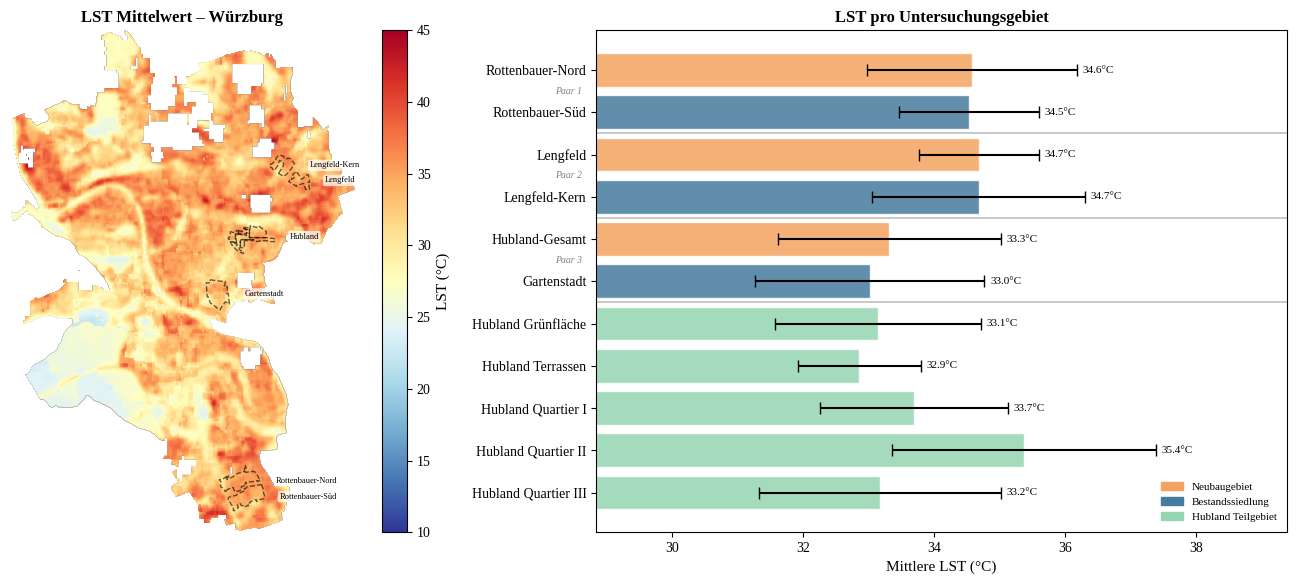

In [2]:
#  NOTEBOOK 3 – LST
#  Aufgabe: LST berechnen, Mittelwert bilden, Gebiete auswerten
#  Input:   Landsat/Clipped/ (ST_B10, CLEAR_MASK)
#  Output:  LST/Szenen/ + LST/LST_MEAN.tif + Grafiken/

import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import os
from rasterio.mask import mask as rio_mask
from rasterio.transform import rowcol

# SETUP

base        = "/content/drive/MyDrive/Colab_Notebooks"
clip_path   = f"{base}/Landsat/Clipped"
out_path    = f"{base}/LST"
szenen_path = f"{base}/LST/Szenen"

os.makedirs(szenen_path,        exist_ok=True)
os.makedirs(f"{base}/Grafiken", exist_ok=True)

NODATA  = -9999.0
LST_MIN = -10.0   # °C
LST_MAX =  60.0   # °C

# ── Farben ────────────────────────────────────────────────────────────────────
FARBE_NEUBAU  = "#f4a261"
FARBE_BESTAND = "#457b9d"
FARBE_TEILGEB = "#95d5b2"

# ── APA 7 Plotstil ────────────────────────────────────────────────────────────
mpl.rcParams["font.family"]      = "serif"
mpl.rcParams["font.serif"]       = ["Liberation Serif", "DejaVu Serif", "Georgia"]
mpl.rcParams["font.size"]        = 12
mpl.rcParams["axes.titlesize"]   = 12
mpl.rcParams["axes.labelsize"]   = 11
mpl.rcParams["xtick.labelsize"]  = 10
mpl.rcParams["ytick.labelsize"]  = 10
mpl.rcParams["legend.fontsize"]  = 10
mpl.rcParams["axes.facecolor"]   = "white"
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.grid"]        = False
mpl.rcParams["savefig.dpi"]      = 300
mpl.rcParams["savefig.bbox"]     = "tight"
mpl.rcParams["legend.frameon"]   = False

# ── Szenen-IDs aus Clipped-Ordner ableiten ────────────────────────────────────
scene_ids = sorted(set(
    f.replace("_CLEAR_MASK.tif", "")
    for f in os.listdir(clip_path)
    if f.endswith("_CLEAR_MASK.tif")
))
print(f"✅ {len(scene_ids)} Szenen gefunden:")
for s in scene_ids:
    print(f"  - {s}")

# ── Gebiete laden ─────────────────────────────────────────────────────────────
# Hubland-Gesamt bereits in Notebook 1 als Shapefile gespeichert
shapefile_pfade = {
    "Rottenbauer-Nord":     f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_Nord.shp",
    "Rottenbauer-Süd":      f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_alt.shp",
    "Lengfeld":             f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld.shp",
    "Lengfeld-Kern":        f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld_alt.shp",
    "Hubland Grünfläche":   f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hubland_Gruenflaeche.shp",
    "Hubland Terrassen":    f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hublandterrassen.shp",
    "Hubland Quartier I":   f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_I.shp",
    "Hubland Quartier II":  f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_II_plus_BBP_70.shp",
    "Hubland Quartier III": f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_III.shp",
    "Hubland-Gesamt":       f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hubland_Gesamt.shp",
    "Gartenstadt":          f"{base}/Shapefiles_Gebiete/Gartenstadt/Shape_Gartenstadt.shp",
}

gebiete_gdfs  = {name: gpd.read_file(pfad)
                 for name, pfad in shapefile_pfade.items()}
gebiete_final = gebiete_gdfs
hubland_gesamt = gebiete_gdfs["Hubland-Gesamt"]

print(f"✅ {len(gebiete_final)} Gebiete geladen")


# SCHRITT 1: LST pro Szene berechnen
lst_stack = []
meta_ref  = None

for scene_id in scene_ids:
    print(f"\n{'='*60}")
    print(f"🔄 {scene_id}")

    st_path   = os.path.join(clip_path, f"{scene_id}_ST_B10_clip.tif")
    mask_path = os.path.join(clip_path, f"{scene_id}_CLEAR_MASK.tif")

    # ── Dateien prüfen ────────────────────────────────────────────────────────
    fehlend = [p for p in [st_path, mask_path]
               if not os.path.exists(p)]
    if fehlend:
        print(f"  ⚠️ Fehlende Dateien: {fehlend} – Szene übersprungen!")
        continue

    # ── ST_B10 laden ──────────────────────────────────────────────────────────
    with rasterio.open(st_path) as src:
        st         = src.read(1).astype(np.float32)
        meta       = src.meta.copy()
        src_nodata = src.nodata
    print(f"  ℹ️  ST_B10 NoData-Wert: {src_nodata}")

    # ── Wolkenmaske laden (aus Notebook 1) ────────────────────────────────────
    with rasterio.open(mask_path) as src:
        clear_mask = src.read(1)

    pct = clear_mask.sum() / clear_mask.size * 100
    print(f"  ✔ Klare Pixel: {clear_mask.sum():,} / "
          f"{clear_mask.size:,} ({pct:.1f}%)")

    # ── Kombinierte Maske: Wolke + Null + NoData ──────────────────────────────
    # Pixel müssen alle drei Bedingungen erfüllen um gültig zu sein
    valid_mask = (
        (clear_mask == 1) &
        (st != 0) &
        (st != src_nodata if src_nodata is not None else True)
    )
    st_clean = np.where(valid_mask, st, np.nan)

    # ── DN → Kelvin → Celsius ─────────────────────────────────────────────────
    # Schritt 1: DN → Kelvin (Landsat Collection 2 Skalierungsformel)
    # T[K] = DN × 0.00341802 + 149.0
    # Schritt 2: Kelvin → Celsius
    # T[°C] = T[K] − 273.15
    st_celsius = np.where(
        ~np.isnan(st_clean),
        (st_clean * 0.00341802 + 149.0) - 273.15,
        np.nan
    )

    # ── Plausibilitätsfilter ──────────────────────────────────────────────────
    st_celsius = np.where(
        (st_celsius >= LST_MIN) & (st_celsius <= LST_MAX),
        st_celsius, np.nan
    )

    valid = st_celsius[~np.isnan(st_celsius)]
    if len(valid) == 0:
        print("  ⚠️ Keine gültigen Pixel – Szene übersprungen!")
        continue

    print(f"  ✔ LST | Min: {np.nanmin(valid):.1f}°C  "
          f"Mean: {np.nanmean(valid):.1f}°C  Max: {np.nanmax(valid):.1f}°C")

    # ── Pro Szene speichern ───────────────────────────────────────────────────
    out_meta = meta.copy()
    out_meta.update(dtype=rasterio.float32, count=1, nodata=NODATA)
    szene_out = os.path.join(szenen_path, f"{scene_id}_LST_Celsius.tif")
    arr_out   = np.where(np.isnan(st_celsius), NODATA, st_celsius)

    with rasterio.open(szene_out, "w", **out_meta) as dst:
        dst.write(arr_out.astype(np.float32), 1)
    print(f"  ✔ Gespeichert: {scene_id}_LST_Celsius.tif")

    lst_stack.append(st_celsius)
    if meta_ref is None:
        meta_ref = out_meta.copy()


# SCHRITT 2: Pixelweiser Mittelwert über alle Szenen


lst_stack = np.array(lst_stack)
print(f"\nShape des LST-Stacks: {lst_stack.shape} "
      f"→ {lst_stack.shape[0]} Szenen")

lst_mean = np.nanmean(lst_stack, axis=0)

lst_mean_path = os.path.join(out_path, "LST_MEAN.tif")
arr_out = np.where(np.isnan(lst_mean), NODATA, lst_mean)
with rasterio.open(lst_mean_path, "w", **meta_ref) as dst:
    dst.write(arr_out.astype(np.float32), 1)
print(f"✔ LST_MEAN gespeichert")
print(f"  Mean: {np.nanmean(lst_mean):.1f}°C")
print(f"  Min:  {np.nanmin(lst_mean):.1f}°C")
print(f"  Max:  {np.nanmax(lst_mean):.1f}°C")


# SCHRITT 3: Gebietsauswertung


def lst_stats(gdf, raster_path, nodata=NODATA):
    """Schneidet LST_MEAN auf Gebiet zu und berechnet Statistiken."""
    with rasterio.open(raster_path) as src:
        gdf_reproj = gdf.to_crs(src.crs)
        geoms      = list(gdf_reproj.geometry)
        clipped, _ = rio_mask(src, geoms, crop=True, nodata=nodata)
    arr = clipped[0].astype(np.float32)
    arr[arr == nodata] = np.nan
    # Plausibilitätsfilter nochmals anwenden
    arr[arr < LST_MIN] = np.nan
    arr[arr > LST_MAX] = np.nan
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        return {"mean": np.nan, "min": np.nan,
                "max": np.nan, "std": np.nan, "n": 0}
    return {
        "mean": np.nanmean(valid),
        "min":  np.nanmin(valid),
        "max":  np.nanmax(valid),
        "std":  np.nanstd(valid),
        "n":    len(valid),
    }

print("\n" + "=" * 68)
print(f"{'Gebiet':<25} {'Mean':>7} {'Min':>7} {'Max':>7} "
      f"{'Std':>7} {'n':>6}")
print("=" * 68)

ergebnisse_lst = {}
for name, gdf in gebiete_final.items():
    s = lst_stats(gdf, lst_mean_path)
    ergebnisse_lst[name] = s
    trennlinie = "─" * 68 if name == "Hubland-Gesamt" else ""
    if trennlinie:
        print(f"  {trennlinie}")
    print(f"  {name:<23} {s['mean']:>6.1f}°C  {s['min']:>6.1f}°C  "
          f"{s['max']:>6.1f}°C  ±{s['std']:>4.1f}°C  {s['n']:>6}")


# SCHRITT 4: Visualisierung


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: LST Karte ─────────────────────────────────────────────────────────
ax = axes[0]
arr_plot = np.where(lst_mean == NODATA, np.nan, lst_mean)
im = ax.imshow(arr_plot, cmap="RdYlBu_r", vmin=10, vmax=45)
plt.colorbar(im, ax=ax, label="LST (°C)", fraction=0.046, pad=0.04)
ax.set_title("LST Mittelwert – Würzburg", fontweight="bold")
ax.axis("off")

# Gebietsumrisse einzeichnen
with rasterio.open(lst_mean_path) as src:
    raster_transform = src.transform
    raster_crs       = src.crs

beschriftet = set()
for name, gdf in gebiete_final.items():
    if name == "Hubland-Gesamt":
        continue
    gdf_reproj = gdf.to_crs(raster_crs)
    geom       = gdf_reproj.geometry.unary_union
    if hasattr(geom, "exterior"):
        xs, ys = geom.exterior.coords.xy
    else:
        xs, ys = geom.convex_hull.exterior.coords.xy
    rows, cols = rowcol(raster_transform, xs, ys)
    ax.plot(cols, rows, color="black", linewidth=1.0,
            linestyle="--", alpha=0.6)
    anzeige_name = "Hubland" if "Hubland" in name else name
    if anzeige_name not in beschriftet:
        if "Hubland" in name:
            hub_reproj = hubland_gesamt.to_crs(raster_crs)
            centroid   = hub_reproj.geometry.unary_union.centroid
        else:
            centroid = geom.centroid
        cr, cc = rowcol(raster_transform, centroid.x, centroid.y)
        ax.annotate(
            anzeige_name,
            xy=(max(cols), cr), xytext=(max(cols) + 15, cr),
            fontsize=6, ha="left", va="center", color="black",
            annotation_clip=False,
            bbox=dict(boxstyle="round,pad=0.2",
                      fc="white", alpha=0.7, ec="none")
        )
        beschriftet.add(anzeige_name)

# ── Plot 2: Balkendiagramm mit Matched Pairs ──────────────────────────────────
ax = axes[1]

reihenfolge = [
    "Rottenbauer-Nord", "Rottenbauer-Süd",
    "Lengfeld",         "Lengfeld-Kern",
    "Hubland-Gesamt",   "Gartenstadt",
    "Hubland Grünfläche", "Hubland Terrassen",
    "Hubland Quartier I", "Hubland Quartier II", "Hubland Quartier III",
]

farben_dict = {
    "Rottenbauer-Nord":     FARBE_NEUBAU,
    "Rottenbauer-Süd":      FARBE_BESTAND,
    "Lengfeld":             FARBE_NEUBAU,
    "Lengfeld-Kern":        FARBE_BESTAND,
    "Hubland-Gesamt":       FARBE_NEUBAU,
    "Gartenstadt":          FARBE_BESTAND,
    "Hubland Grünfläche":   FARBE_TEILGEB,
    "Hubland Terrassen":    FARBE_TEILGEB,
    "Hubland Quartier I":   FARBE_TEILGEB,
    "Hubland Quartier II":  FARBE_TEILGEB,
    "Hubland Quartier III": FARBE_TEILGEB,
}

means  = [ergebnisse_lst[n]["mean"] for n in reihenfolge]
stds   = [ergebnisse_lst[n]["std"]  for n in reihenfolge]
farben = [farben_dict[n]             for n in reihenfolge]

bars = ax.barh(reihenfolge, means, xerr=stds,
               color=farben, alpha=0.85,
               edgecolor="white", capsize=4)
ax.bar_label(bars, fmt="%.1f°C", padding=4, fontsize=8)

# Trennlinien zwischen Paaren
for y in [1.5, 3.5, 5.5]:
    ax.axhline(y=y, color="gray", linewidth=1.2,
               linestyle="-", alpha=0.5)


# Paar-Beschriftung
for y_pos, label in {0.5: "Paar 1",
                     2.5: "Paar 2",
                     4.5: "Paar 3"}.items():
    ax.text(-0.02, y_pos, label,
            transform=ax.get_yaxis_transform(),
            ha="right", va="center",
            fontsize=7, color="gray", style="italic")

# Legende
ax.legend(handles=[
    mpatches.Patch(color=FARBE_NEUBAU,  label="Neubaugebiet"),
    mpatches.Patch(color=FARBE_BESTAND, label="Bestandssiedlung"),
    mpatches.Patch(color=FARBE_TEILGEB, label="Hubland Teilgebiet"),
], fontsize=8, loc="lower right")

ax.set_xlim(min(means) - max(stds) - 2,
            max(means) + max(stds) + 2)
ax.set_xlabel("Mittlere LST (°C)")
ax.set_title("LST pro Untersuchungsgebiet", fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    f"{base}/Grafiken/LST_Auswertung.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
print("✅ Grafik gespeichert: LST_Auswertung.png")
plt.show()

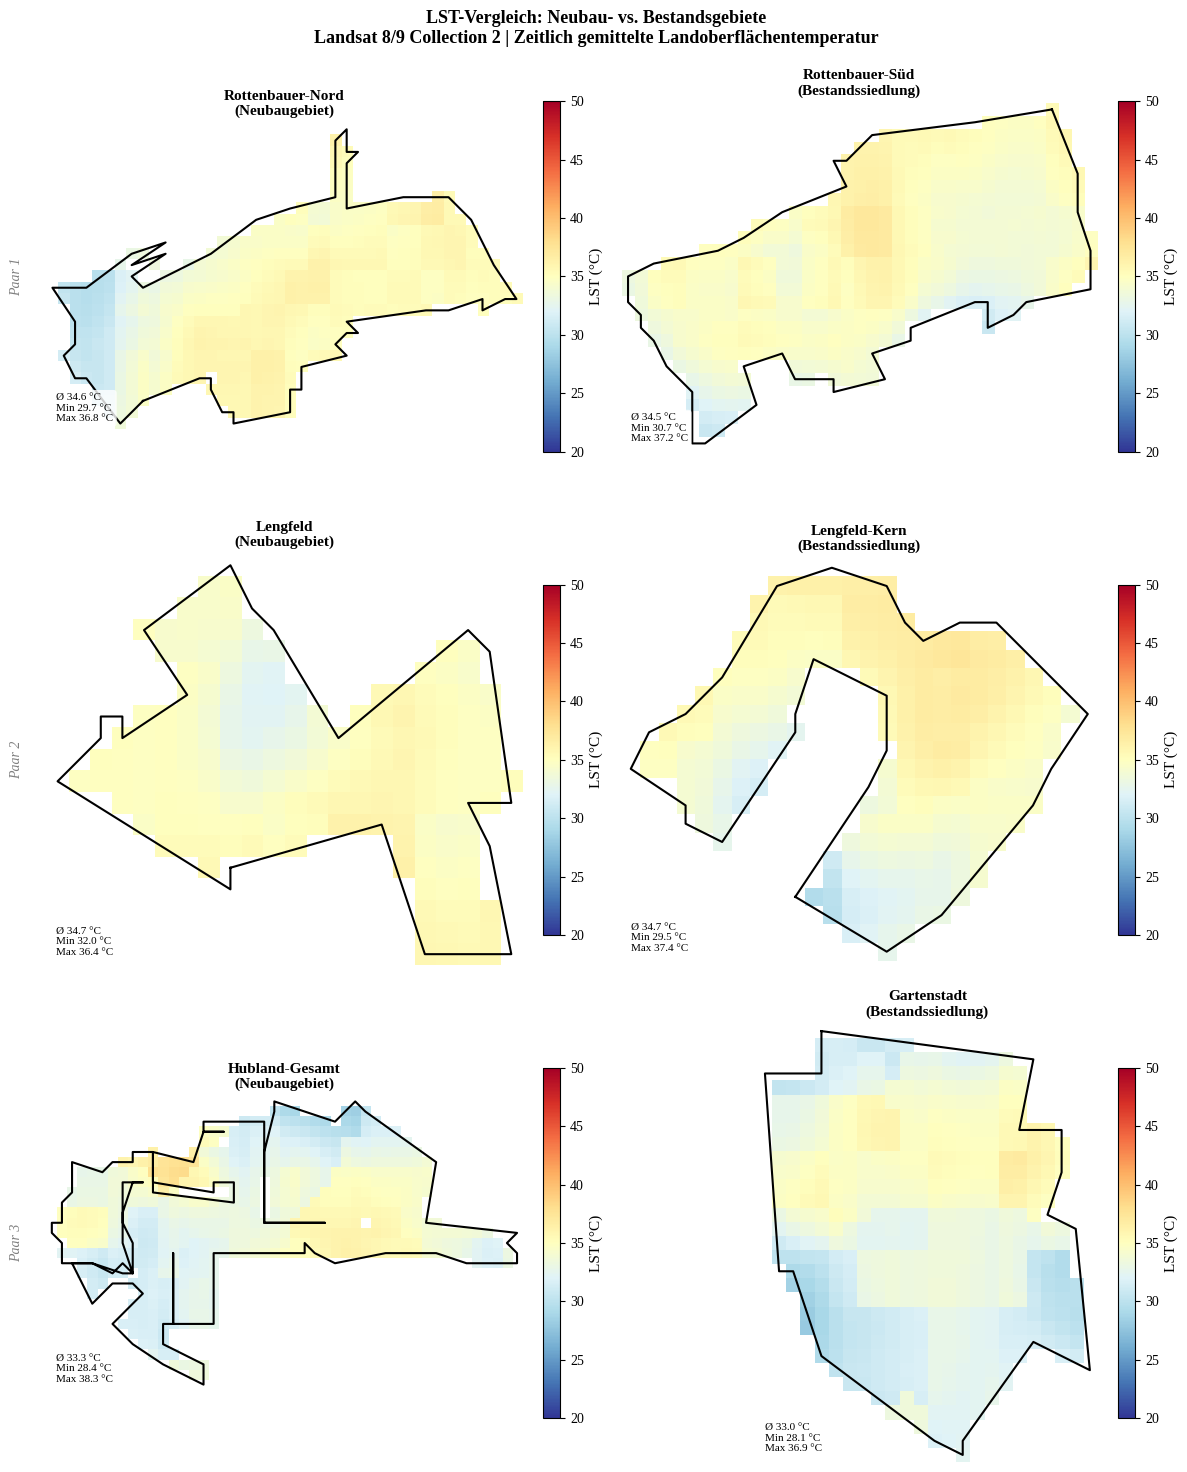

✅ Grafik gespeichert: LST_Paarvergleich_Karten.png


In [3]:
# ── Paarweise LST-Karten der Untersuchungsgebiete ────────────────────────────
from rasterio.mask import mask as rio_mask
import matplotlib.patches as mpatches

paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]

with rasterio.open(lst_mean_path) as src:
    raster_crs = src.crs

fig, axes = plt.subplots(len(paare), 2, figsize=(12, len(paare) * 5))

for row, (neubau, bestand) in enumerate(paare):

    for col, name in enumerate([neubau, bestand]):

        ax = axes[row, col]

        gdf = gebiete_final[name].to_crs(raster_crs)

        with rasterio.open(lst_mean_path) as src:
            clipped, clip_transform = rio_mask(
                src,
                list(gdf.geometry),
                crop=True,
                nodata=NODATA
            )

        arr = clipped[0].astype(np.float32)
        arr[arr == NODATA] = np.nan

        # Plausibilitätsfilter
        arr[(arr < LST_MIN) | (arr > LST_MAX)] = np.nan

        im = ax.imshow(
            arr,
            cmap="RdYlBu_r",
            vmin=20,
            vmax=50
        )

        # Gebietsgrenze
        from rasterio.transform import rowcol as rc

        geom = gdf.geometry.union_all()

        if hasattr(geom, "exterior"):
            xs, ys = geom.exterior.coords.xy
        else:
            xs, ys = geom.convex_hull.exterior.coords.xy

        rows, cols = rc(clip_transform, xs, ys)

        ax.plot(
            cols,
            rows,
            color="black",
            linewidth=1.5
        )

        gruppe = (
            "Neubaugebiet"
            if col == 0
            else "Bestandssiedlung"
        )

        ax.set_title(
            f"{name}\n({gruppe})",
            fontsize=11,
            fontweight="bold"
        )

        ax.axis("off")

        # Colorbar
        plt.colorbar(
            im,
            ax=ax,
            label="LST (°C)",
            fraction=0.046,
            pad=0.04,
            shrink=0.8
        )

        # Statistikbox
        valid = arr[~np.isnan(arr)]

        if len(valid) > 0:

            stats_text = (
                f"Ø {np.nanmean(valid):.1f} °C\n"
                f"Min {np.nanmin(valid):.1f} °C\n"
                f"Max {np.nanmax(valid):.1f} °C"
            )

            ax.text(
                0.02,
                0.02,
                stats_text,
                transform=ax.transAxes,
                fontsize=8,
                va="bottom",
                ha="left",
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    alpha=0.8,
                    ec="none"
                )
            )

    # Paarbeschriftung links
    axes[row, 0].text(
        -0.05,
        0.5,
        f"Paar {row+1}",
        transform=axes[row, 0].transAxes,
        fontsize=10,
        color="gray",
        style="italic",
        va="center",
        ha="right",
        rotation=90
    )

fig.suptitle(
    "LST-Vergleich: Neubau- vs. Bestandsgebiete\n"
    "Landsat 8/9 Collection 2 | Zeitlich gemittelte Landoberflächentemperatur",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{base}/Grafiken/LST_Paarvergleich_Karten.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Grafik gespeichert: LST_Paarvergleich_Karten.png")

Gebiet                    Ø LST (°C)     Gruppe
  Rottenbauer-Nord          34.5780   Neubau
  Rottenbauer-Süd           34.5321   Bestand
  ───────────────────────────────────────────────
  Lengfeld                  34.6900   Neubau
  Lengfeld-Kern             34.6820   Bestand
  ───────────────────────────────────────────────
  Hubland-Gesamt            33.3184   Neubau
  Gartenstadt               33.0177   Bestand
  ───────────────────────────────────────────────

  Mittelwert Neubau         34.1955
  Mittelwert Bestand        34.0772

── Differenzen pro Paar (Neubau − Bestand) ──
  Rottenbauer               +0.0459 °C   ↑ Neubau wärmer
  Lengfeld                  +0.0081 °C   ↑ Neubau wärmer
  Hubland//Gartenstadt      +0.3007 °C   ↑ Neubau wärmer

── Wilcoxon-Vorzeichen-Rang-Test (zweiseitig) ──
   Teststatistik W: 0.000
   p-Wert:          0.250
   n Paare:         3
   → Nicht signifikant (p ≥ 0.10) ❌
      Hinweis: Bei n=3 Paaren ist die statistische
      Power sehr begrenzt –

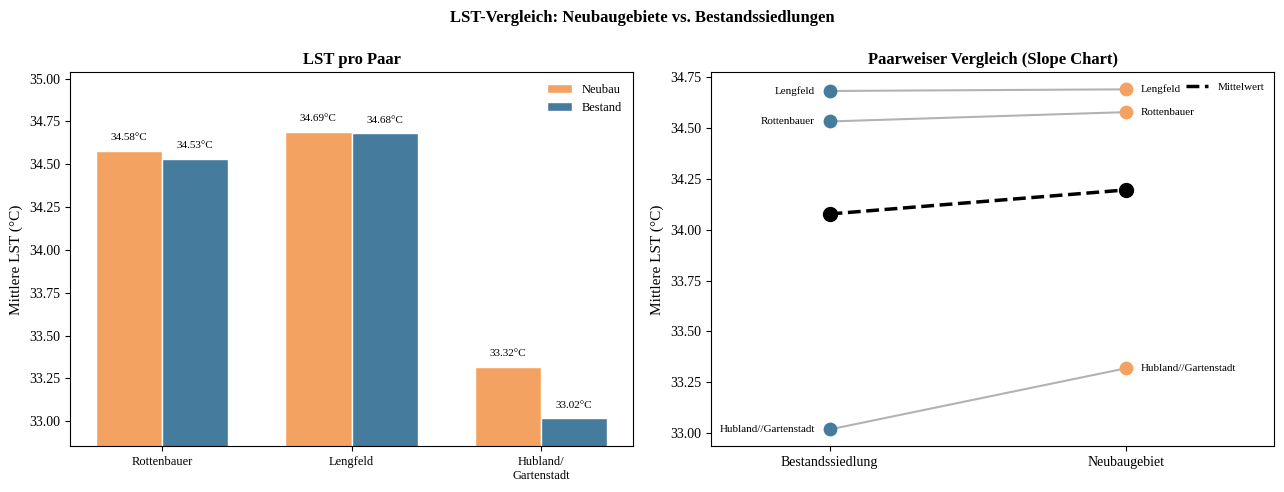

In [4]:
# SCHRITT 5: Statistische Analyse – Wilcoxon Paarvergleich LST
from scipy import stats

# ── Paare definieren ──────────────────────────────────────────────────────────
paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]
paar_labels = ["Rottenbauer", "Lengfeld", "Hubland/\nGartenstadt"]

# ── Funktion: mittlere LST pro Gebiet ─────────────────────────────────────────
# Greift auf lst_mean_path und gebiete_final aus Schritt 3/4 zurück
def lst_mean_gebiet(gdf):
    with rasterio.open(lst_mean_path) as src:
        gdf_reproj = gdf.to_crs(src.crs)
        geoms      = list(gdf_reproj.geometry)
        clipped, _ = rio_mask(src, geoms, crop=True, nodata=np.nan)
    arr = clipped[0].astype(np.float32)
    arr[arr < LST_MIN] = np.nan
    arr[arr > LST_MAX] = np.nan
    return float(np.nanmean(arr))

# ── Mittelwerte berechnen ─────────────────────────────────────────────────────
neubau_lst  = []
bestand_lst = []

print("=" * 57)
print(f"{'Gebiet':<25} {'Ø LST (°C)':>10} {'Gruppe':>10}")
print("=" * 57)

for neubau, bestand in paare:
    mean_neubau  = lst_mean_gebiet(gebiete_final[neubau])
    mean_bestand = lst_mean_gebiet(gebiete_final[bestand])
    neubau_lst.append(mean_neubau)
    bestand_lst.append(mean_bestand)
    print(f"  {neubau:<23} {mean_neubau:>9.4f}   Neubau")
    print(f"  {bestand:<23} {mean_bestand:>9.4f}   Bestand")
    print(f"  {'─' * 47}")

print(f"\n  {'Mittelwert Neubau':<23} {np.mean(neubau_lst):>9.4f}")
print(f"  {'Mittelwert Bestand':<23} {np.mean(bestand_lst):>9.4f}")
print("=" * 57)

# ── Differenzen pro Paar ──────────────────────────────────────────────────────
diff_paare = [n - b for n, b in zip(neubau_lst, bestand_lst)]

print("\n── Differenzen pro Paar (Neubau − Bestand) ──")
for label, d in zip(paar_labels, diff_paare):
    richtung = "↑ Neubau wärmer" if d > 0 else "↓ Bestand wärmer"
    print(f"  {label.replace(chr(10), '/'):<25} {d:>+.4f} °C   {richtung}")

# ── Wilcoxon-Vorzeichen-Rang-Test ─────────────────────────────────────────────
stat, p = stats.wilcoxon(neubau_lst, bestand_lst, alternative='two-sided')

print(f"\n── Wilcoxon-Vorzeichen-Rang-Test (zweiseitig) ──")
print(f"   Teststatistik W: {stat:.3f}")
print(f"   p-Wert:          {p:.3f}")
print(f"   n Paare:         {len(paare)}")

if p < 0.05:
    print("   → Signifikant (p < 0.05) ✅")
elif p < 0.10:
    print("   → Tendenz erkennbar (p < 0.10) ⚠️")
else:
    print("   → Nicht signifikant (p ≥ 0.10) ❌")
    print("      Hinweis: Bei n=3 Paaren ist die statistische")
    print("      Power sehr begrenzt – deskriptive Unterschiede")
    print("      bleiben dennoch inhaltlich interpretierbar!")

# SCHRITT 6: Visualisierung Paarvergleich

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Gruppiertes Balkendiagramm ───────────────────────────────────────
ax1 = axes[0]
x      = np.arange(len(paare))
breite = 0.35

balken_neubau  = ax1.bar(x - breite/2, neubau_lst,  breite,
                          label="Neubau",  color=FARBE_NEUBAU,
                          edgecolor="white")
balken_bestand = ax1.bar(x + breite/2, bestand_lst, breite,
                          label="Bestand", color=FARBE_BESTAND,
                          edgecolor="white")

for bar in balken_neubau:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{bar.get_height():.2f}°C",
             ha="center", va="bottom", fontsize=8)
for bar in balken_bestand:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{bar.get_height():.2f}°C",
             ha="center", va="bottom", fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(paar_labels, fontsize=9)
ax1.set_ylabel("Mittlere LST (°C)")
ax1.set_title("LST pro Paar", fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_ylim(min(neubau_lst + bestand_lst) * 0.995,
             max(neubau_lst + bestand_lst) * 1.01)

# ── Plot 2: Slope Chart ───────────────────────────────────────────────────────
ax2 = axes[1]

for label, n, b in zip(paar_labels, neubau_lst, bestand_lst):
    ax2.plot([0, 1], [b, n], color="gray",
             linewidth=1.5, alpha=0.6, zorder=1)
    ax2.scatter(0, b, color=FARBE_BESTAND, s=80, zorder=2)
    ax2.scatter(1, n, color=FARBE_NEUBAU,  s=80, zorder=2)
    ax2.text(1.05, n, label.replace("\n", "/"),
             va="center", fontsize=8)
    ax2.text(-0.05, b, label.replace("\n", "/"),
             va="center", ha="right", fontsize=8)

ax2.plot([0, 1],
         [np.mean(bestand_lst), np.mean(neubau_lst)],
         color="black", linewidth=2.5, linestyle="--",
         zorder=3, label="Mittelwert")
ax2.scatter([0, 1],
            [np.mean(bestand_lst), np.mean(neubau_lst)],
            color="black", s=100, zorder=4)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Bestandssiedlung", "Neubaugebiet"], fontsize=10)
ax2.set_xlim(-0.4, 1.5)
ax2.set_ylabel("Mittlere LST (°C)")
ax2.set_title("Paarweiser Vergleich (Slope Chart)", fontweight="bold")
ax2.legend(fontsize=8)

plt.suptitle(
    "LST-Vergleich: Neubaugebiete vs. Bestandssiedlungen",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    f"{base}/Grafiken/LST_Paarvergleich.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
print("✅ Grafik gespeichert: LST_Paarvergleich.png")
plt.show()

In [5]:
# ── Funktion: LST-Statistiken pro Gebiet ─────────────────────────────────────
def lst_stats_gebiet(gdf):
    with rasterio.open(lst_mean_path) as src:
        gdf_reproj = gdf.to_crs(src.crs)
        geoms      = list(gdf_reproj.geometry)
        clipped, _ = rio_mask(src, geoms, crop=True, nodata=np.nan)
    arr = clipped[0].astype(np.float32)
    arr[arr < LST_MIN] = np.nan
    arr[arr > LST_MAX] = np.nan
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        return {"mean": np.nan, "min": np.nan, "max": np.nan}
    return {
        "mean": float(np.nanmean(valid)),
        "min":  float(np.nanmin(valid)),
        "max":  float(np.nanmax(valid)),
    }

# ── Statistiken berechnen ─────────────────────────────────────────────────────
neubau_mean, bestand_mean = [], []
neubau_min,  bestand_min  = [], []
neubau_max,  bestand_max  = [], []

print("=" * 75)
print(f"{'Gebiet':<25} {'Ø LST':>7} {'Min':>7} {'Max':>7} {'Gruppe':>10}")
print("=" * 75)

for neubau, bestand in paare:
    s_n = lst_stats_gebiet(gebiete_final[neubau])
    s_b = lst_stats_gebiet(gebiete_final[bestand])

    neubau_mean.append(s_n["mean"]); bestand_mean.append(s_b["mean"])
    neubau_min.append(s_n["min"]);   bestand_min.append(s_b["min"])
    neubau_max.append(s_n["max"]);   bestand_max.append(s_b["max"])

    print(f"  {neubau:<23} {s_n['mean']:>7.2f} {s_n['min']:>7.2f} {s_n['max']:>7.2f}   Neubau")
    print(f"  {bestand:<23} {s_b['mean']:>7.2f} {s_b['min']:>7.2f} {s_b['max']:>7.2f}   Bestand")
    print(f"  {'─' * 65}")

print("=" * 75)

# ── Wilcoxon für Mean, Min und Max ───────────────────────────────────────────
print("\n── Wilcoxon-Vorzeichen-Rang-Tests (zweiseitig, n=3) ──")
print("=" * 55)

for metrik, n_werte, b_werte in [
    ("Mittelwert", neubau_mean, bestand_mean),
    ("Minimum",    neubau_min,  bestand_min),
    ("Maximum",    neubau_max,  bestand_max),
]:
    diff = [n - b for n, b in zip(n_werte, b_werte)]
    try:
        stat, p = stats.wilcoxon(n_werte, b_werte, alternative="two-sided")
        sig = "✅ p < 0.05" if p < 0.05 else ("⚠️ p < 0.10" if p < 0.10 else "❌ n.s.")
        print(f"  {metrik:<12} W={stat:.1f}  p={p:.3f}  {sig}")
        print(f"             Differenzen: {[f'{d:+.2f}' for d in diff]}")
    except Exception as e:
        print(f"  {metrik:<12} Test nicht möglich: {e}")

print("=" * 55)
print("  Hinweis: Bei n=3 Paaren ist die statistische Power")
print("  stark eingeschränkt – deskriptive Befunde ergänzend")
print("  interpretieren.")

Gebiet                      Ø LST     Min     Max     Gruppe
  Rottenbauer-Nord          34.58   29.68   36.77   Neubau
  Rottenbauer-Süd           34.53   30.70   37.18   Bestand
  ─────────────────────────────────────────────────────────────────
  Lengfeld                  34.69   32.04   36.37   Neubau
  Lengfeld-Kern             34.68   29.49   37.40   Bestand
  ─────────────────────────────────────────────────────────────────
  Hubland-Gesamt            33.32   28.36   38.27   Neubau
  Gartenstadt               33.02   28.06   36.88   Bestand
  ─────────────────────────────────────────────────────────────────

── Wilcoxon-Vorzeichen-Rang-Tests (zweiseitig, n=3) ──
  Mittelwert   W=0.0  p=0.250  ❌ n.s.
             Differenzen: ['+0.05', '+0.01', '+0.30']
  Minimum      W=2.0  p=0.750  ❌ n.s.
             Differenzen: ['-1.02', '+2.55', '+0.31']
  Maximum      W=3.0  p=1.000  ❌ n.s.
             Differenzen: ['-0.41', '-1.02', '+1.39']
  Hinweis: Bei n=3 Paaren ist die statistische